# LAB 02 WEEK 05 -- Bivariate Analysis:

Diving into Amazon UK Product Insights


## Part 1: Examining Amazon UK Best-Seller Trends Across Categories

Question: Do specific categories have a higher "hit rate" for best-seller status than others?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import scipy.stats as stats

# Define path for csv
file_path = r".\amazon_db\amazon_uk_products.csv"

# Load data
df = pd.read_csv(file_path)

# Cleaning & Type casting (from Lab Part1)
df['price'] = pd.to_numeric(df['price'], errors='coerce') # Force numeric price column

# Use df_rated again to exclude zero star items (from Lab Part1) 
df_rated = df[df['stars'] > 0].dropna(subset=['stars']).copy()

df_rated.head(10) # Look at the first few entries with 1-5 stars

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
5,6,B09B97WSLF,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
6,7,B09B9615X2,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
7,8,B01MTB55WH,Anker Soundcore 2 Portable Bluetooth Speaker w...,4.7,103673,39.99,False,0,Hi-Fi Speakers
8,9,B016MO90GW,"Bluetooth Speaker, Anker Soundcore Speaker Upg...",4.7,29909,29.99,False,0,Hi-Fi Speakers
9,10,B09ZQF5GZW,RIENOK Bluetooth Speaker Portable Wireless Blu...,4.5,16014,29.99,False,0,Hi-Fi Speakers


In [2]:
# Eliminate the "Sports & Outdoor" category if needed (from Lab Part1)

# Create a subset df_tier2 of Top 2-11 excluding Sports  
category_counts = df['category'].value_counts()
tier_2_categories = category_counts.iloc[1:11].index

df_tier2 = df_rated[df_rated['category'].isin(tier_2_categories)]

# Set simple white grid style
sns.set_theme(style="whitegrid")

In [32]:
# Crosstab of Categories and Best-Seller status
crosstab_bs = pd.crosstab(df['category'], df['isBestSeller'])
bs_proportion = crosstab_bs.div(crosstab_bs.sum(1), axis=0)[True].sort_values(ascending=False)

# Chi2 & CramersV Tests
chi2, p, dof, expected = chi2_contingency(crosstab_bs) # Degrees of freedom -- dof = (rows-1)x(cols-1)
n = crosstab_bs.sum().sum() # Latex for CramersV rule: $$V = \sqrt{\frac{\chi^2}{n(min(C-1, R-1))}}$$
cramers_v = np.sqrt((chi2/n) / min(crosstab_bs.shape[0]-1, crosstab_bs.shape[1]-1))

print(f"Chi2 P-value: {p:.8f}")
print(f"Cramer's V: {cramers_v:.8f}")
print(f"Degrees of Freedom: {dof}")

Chi2 P-value: 0.00000000
Cramer's V: 0.12228294
Degrees of Freedom: 295


In [37]:
# Get List of Best-Sellers over all Categories 
crosstab_bs.head(50)


isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
Agricultural Equipment & Supplies,8421,109
Alexa Built-In Devices,106,1
Art & Craft Supplies,253,5
Arts & Crafts,9319,230


In [39]:
bestseller_cats = crosstab_bs[True].sort_values(ascending=False)
bestseller_cats.head(50)

category
Grocery                                       556
Health & Personal Care                        552
Baby                                          341
Sports & Outdoors                             330
Power & Hand Tools                            306
Beauty                                        302
Pet Supplies                                  285
Arts & Crafts                                 230
Women                                         213
Men                                           169
PC & Video Games                              157
Storage & Organisation                        155
Hardware                                      146
Large Appliances                              144
Building Supplies                             134
Office Supplies                               133
Customers' Most Loved                         111
Agricultural Equipment & Supplies             109
Gardening                                     106
Luggage and travel gear                  

## Remarks on Statistical Tests 
The Chi-2 test shows a very small p-value of 0.00 (p < 0.05), implying that the product category does influence its best-seller ranking. But the low Cramers V test of 0.1223 suggests that it is relatively weak, and there are many other factors that drive up sales and accordingly, 4 and 5 star ratings. 

As suspected, the best rated Best sellers are not always found in the categories with the most product choices. In fact, big players like the massive "Sports" category disappear much further down the list, while the real winners are the affordable, "boring" standards of everyday life: Grocery orders, Baby wipes and nappies, Cosmetics and beauty products, Building materials and other household staples. 

## Part 2: Exploring Product Prices and Ratings Across Categories and Brands

Question: How do different product categories influence product prices?

In [ ]:
# Remove Outliers by using IQR only
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create new df just with IQR Q1-Q3 for price analysis
df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()
# Category counts as filter
category_counts = df['category'].value_counts()
# category_counts


### Violin & Box Plots

Question: Which product categories tend to have the highest median price, across all categories?


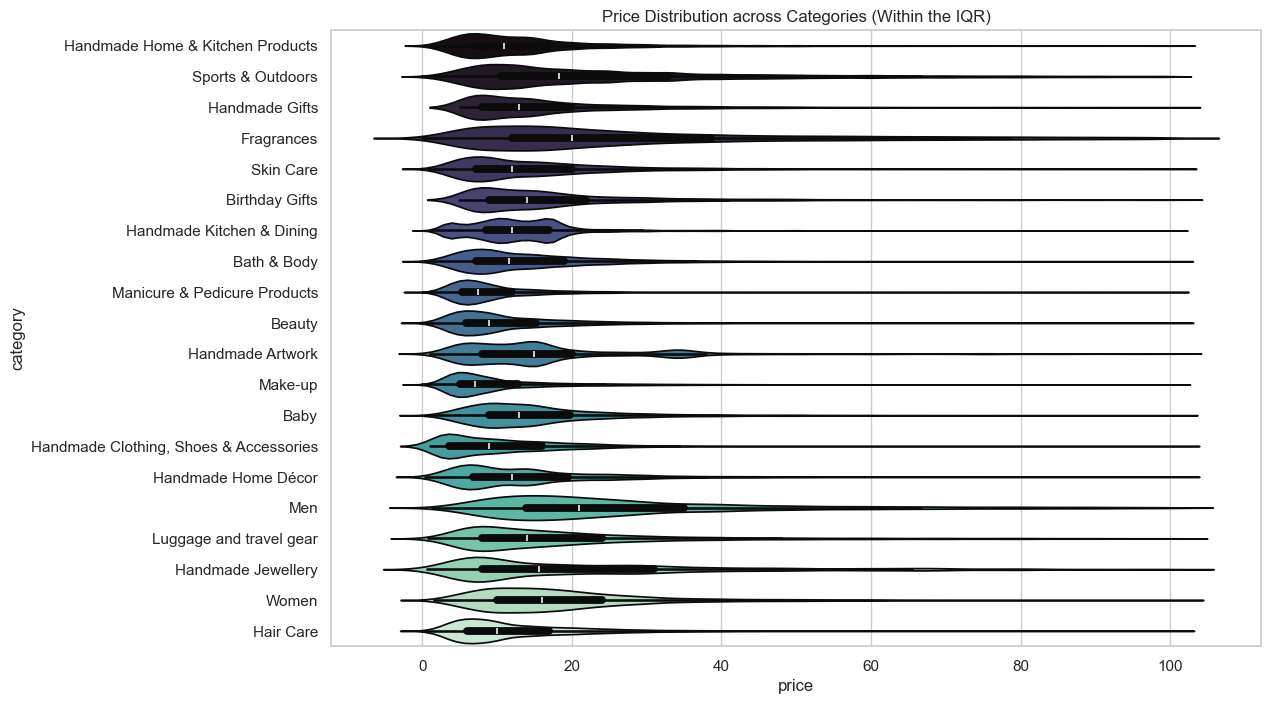

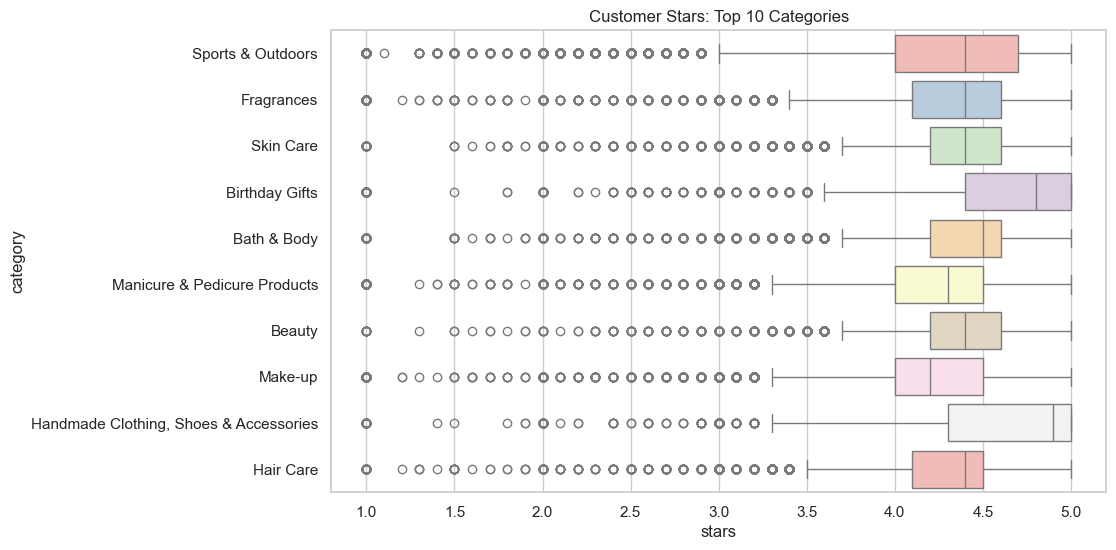

In [ ]:
# Data Viz (Violin & Box Plots - Top 10 and 20 categories only) 

# Violin Plot -- Price Distribution Top 20 only
plt.figure(figsize=(12, 8))
sns.violinplot(data=df_no_outliers[df_no_outliers['category'].isin(category_counts.head(20).index)], 
               x='price', y='category', palette='mako', hue='category', legend=False)
plt.title('Price Distribution across Categories (Within the IQR)')
plt.show()

# Box Plot (Top 10 Cats) - Stars (Rating) Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_rated[df_rated['category'].isin(category_counts.head(10).index)], 
            x='stars', y='category', palette='Pastel1', hue='category', legend=False)
plt.title('Customer Stars: Top 10 Categories')
plt.show()

# Get Unfiltered Maxima
max_median_price_cat = df_no_outliers.groupby('category')['price'].median().idxmax()
max_median_stars_cat = df_rated.groupby('category')['stars'].median().idxmax()

### Plots of all categories by number of Best-sellers

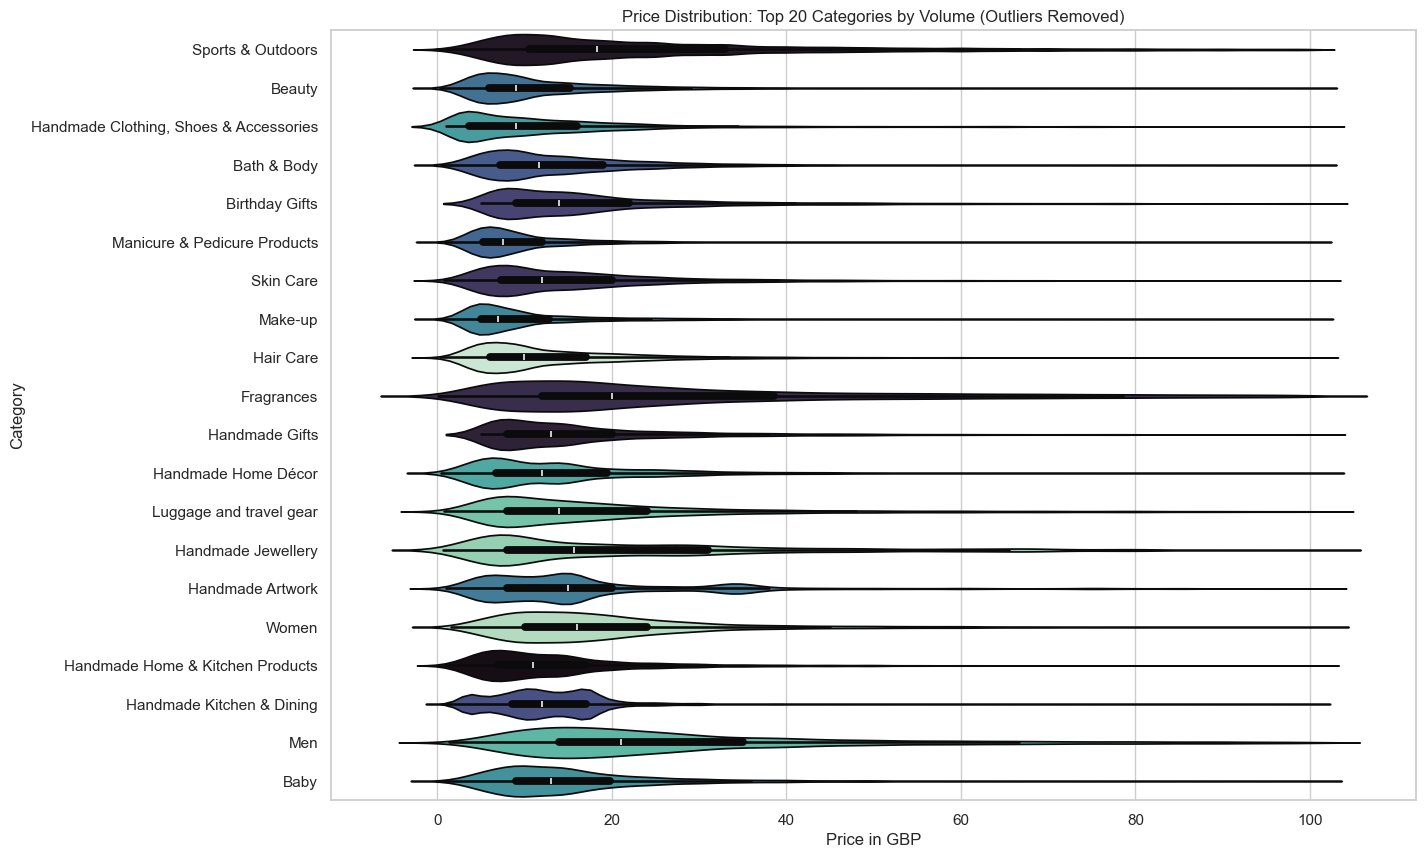

Which product category tends to have the highest median price?
Desktop PCs (£74.00)



In [24]:
# Violin Plot - Price Distribution by Best-Seller Count

# Filter Top 20 by counts
top_20_cats = category_counts.head(20).index
df_violin = df_no_outliers[df_no_outliers['category'].isin(top_20_cats)]

plt.figure(figsize=(14, 10))
sns.violinplot(data=df_violin, x='price', y='category', palette='mako', 
               hue='category', legend=False, order=top_20_cats)
plt.title('Price Distribution: Top 20 Categories by Volume (Outliers Removed)')
plt.xlabel('Price in GBP')
plt.ylabel('Category')
plt.show()

# Highest Median Price
highest_median_price_cat = df_no_outliers.groupby('category')['price'].median().idxmax()
val_median_price = df_no_outliers.groupby('category')['price'].median().max()
print(f"Which product category tends to have the highest median price?")
print(f"{highest_median_price_cat} (£{val_median_price:.2f})\n")


### Bar Chart - Avg. price in Top 10 Best seller categories  

Question: Which product category has the highest average price, across all categories?

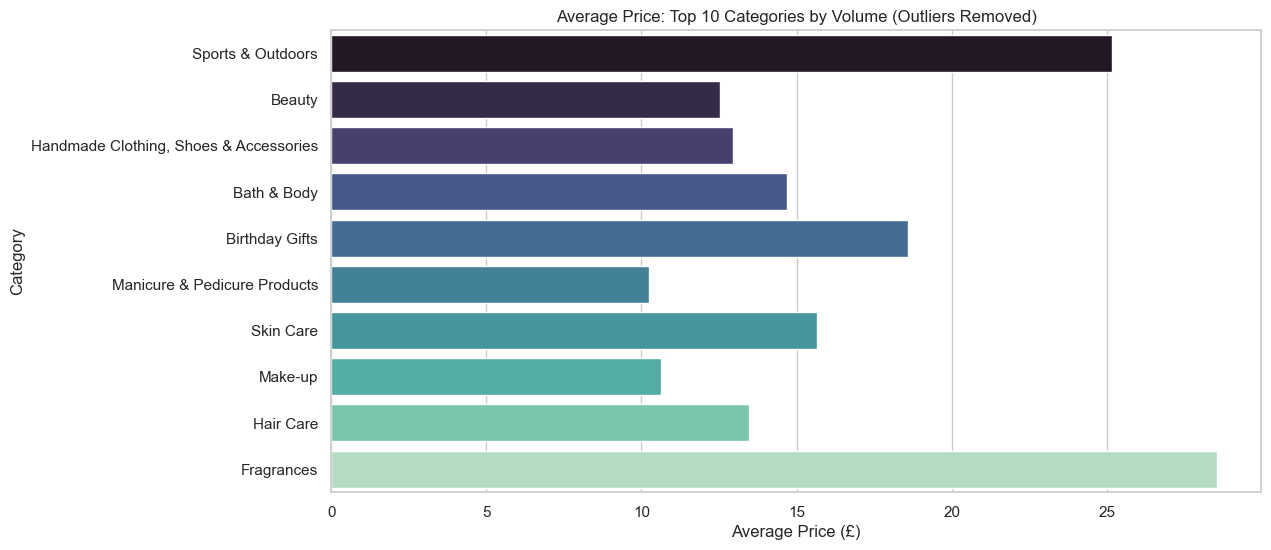

Q: Which product category has the highest average price?
A: Motherboards (£68.77)



In [ ]:
# Bar Charts -- Highest Average Prices in Top 10
top_10_cats = category_counts.head(10).index
df_bar = df_no_outliers[df_no_outliers['category'].isin(top_10_cats)]

# Calculate avg price for just the Top 10
avg_price_top_10 = df_bar.groupby('category')['price'].mean().reindex(top_10_cats).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_price_top_10, x='price', y='category', palette='mako', hue='category', legend=False)
plt.title('Average Price: Top 10 Categories by Volume (Outliers Removed)')
plt.xlabel('Average Price (£)')
plt.ylabel('Category')
plt.show()

# Answer: Highest Average Price (UNFILTERED)
highest_avg_price_cat = df_no_outliers.groupby('category')['price'].mean().idxmax()
val_avg_price = df_no_outliers.groupby('category')['price'].mean().max()

print(f"Q: Which product category has the highest average price?")
print(f"A: {highest_avg_price_cat} (£{val_avg_price:.2f})\n")



### Box Plots -- Ratings/Stars by Category  

Question: Which category tends to receive the highest median rating from customers, across all categories?

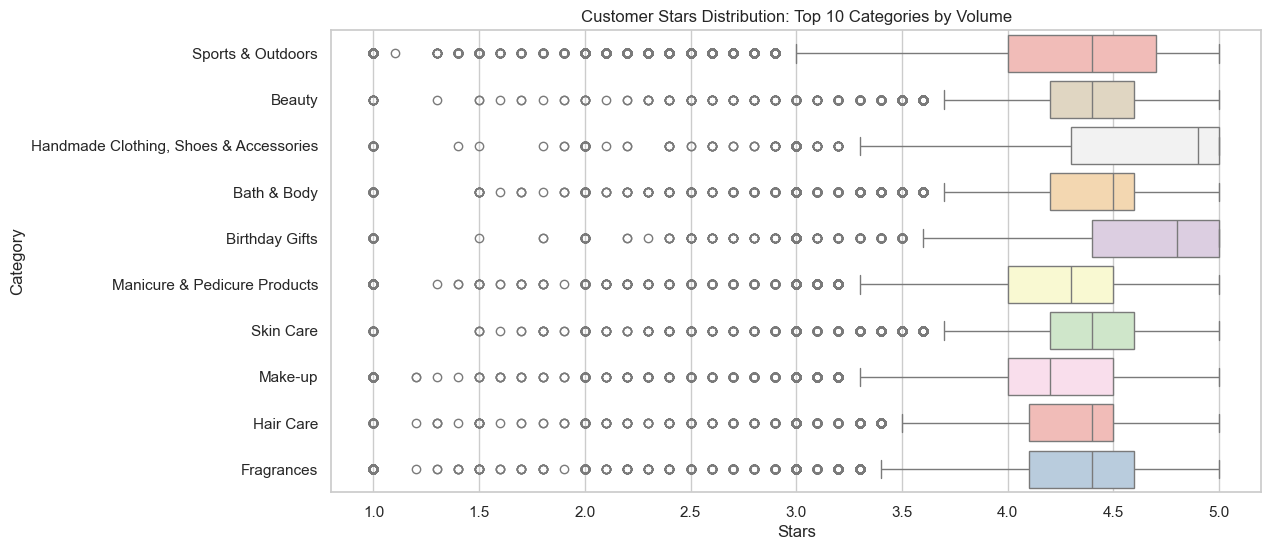

Q: Which category tends to receive the highest median rating from customers?
A: Handmade Artwork (5.0 stars)


In [28]:
# Box Plots -- Rating/Stars Distribution

# Use df_rated again to omit the unrated (Zero star) items
df_box = df_rated[df_rated['category'].isin(top_10_cats)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_box, x='stars', y='category', palette='Pastel1', 
            hue='category', legend=False, order=top_10_cats)
plt.title('Customer Stars Distribution: Top 10 Categories by Volume')
plt.xlabel('Stars')
plt.ylabel('Category')
plt.show()

# Highest Median Rating
highest_median_star_cat = df_rated.groupby('category')['stars'].median().idxmax()
val_median_star = df_rated.groupby('category')['stars'].median().max()
print(f"Q: Which category tends to receive the highest median rating from customers?")
print(f"A: {highest_median_star_cat} ({val_median_star} stars)")


## Part 3: Investigating the Interplay Between Product Prices and Ratings


### Correlation Coefficients

Question: Is there a significant correlation between product price and its rating?


In [ ]:
# Correlation Coefficient
import scipy.stats as stats

correlation = df_rated['price'].corr(df_rated['stars'])
print(f"Correlation (Price vs. Rating): {correlation}")


Correlation (Price vs. Rating): -0.004911823000752931


### Remarks on Price-Ratings Relations

The negative correlation of around -0.005 shows that if users buy more expensive products, they will leave slightly lower ratings. This tendency to rate luxury items more harshly is unsurprising, but the overall effect is smaller than might be expected. So there are likely many factors at work besides price that determine customers' star ratings. 

Notable are the "Handmade" categories that feature a high satisfaction/price correlation -- this shows that even on a massive retail platform like Amazon, consumers reward a more individualistic "Etsy", arts and crafts vibe, with hand-made jewellery, gifts and even kitchen items featuring prominently. 

## Visualizations -- Scatter Plots

Question: What patterns stand out in the relationship between product rating and price?

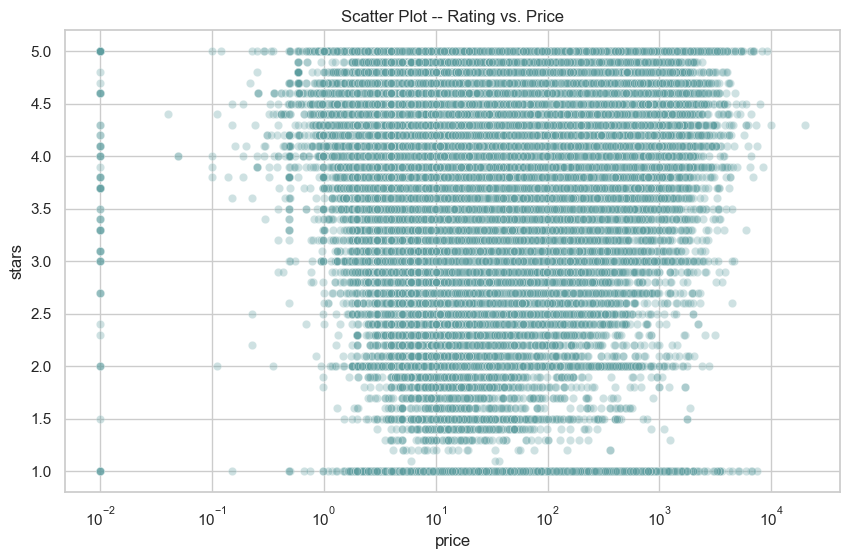

In [44]:
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rated, x='price', y='stars', alpha=0.3, color='cadetblue')
plt.title('Scatter Plot -- Rating vs. Price')

# Use log scale for price (see Part1)
plt.xscale('log') 
plt.show()

## Correlation Heat Map & QQ Plot

Question: Do product prices typically follow a normal distribution? 


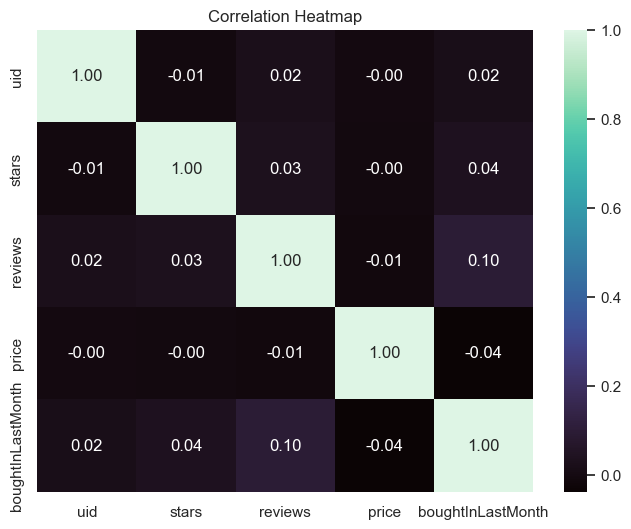

In [45]:
# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_rated.select_dtypes(include=[np.number]).corr(), annot=True, cmap='mako', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

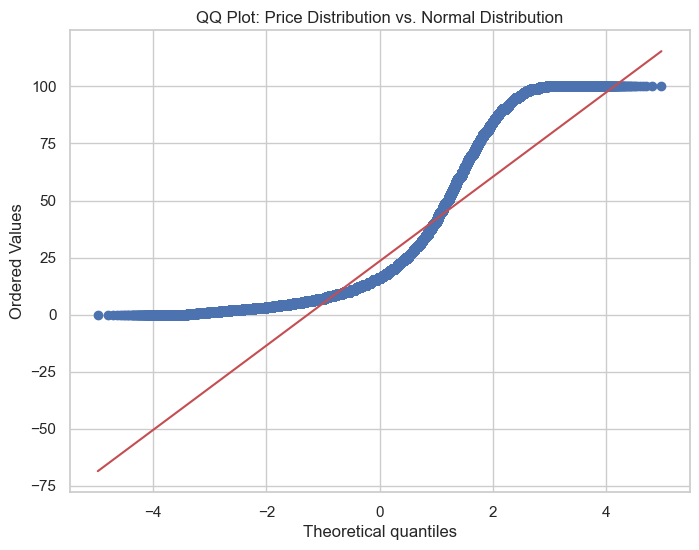

In [46]:
# QQ Plot to Display Normality
plt.figure(figsize=(8, 6))
stats.probplot(df_no_outliers['price'], dist="norm", plot=plt)
plt.title('QQ Plot: Price Distribution vs. Normal Distribution')
plt.show()

### Remarks on Ratings/Price Correlations

The scatter plot above again confirms what was established in Part 1: The sweet spot of ratings/price ratio is around 4.0-4.3 stars, more or less independent of the actual amounts. Between 3 and 5 stars we see almost perfect normal distribution, with the 1 and 2 star bins being the absolute outliers in terms of value for money for customers. Only the discrete integers 1.0, 2.0, 3.0 remain clearly visible as bands in the lower ratings tiers. Combined with a correlation of near Zero, this suggests that customers will judge a 10 pound item more or less by the same standards as a 100 pound item.

As seen above, this is due to the fact that customer satisfaction is (weakly) negatively correlated with product prices, and that it is more likely for unsatisfied customers to leave no rating (zero Stars) than to leave a low one with 1 or 2 stars. 

The Violin plots of price distributions by category from Section 2 above also display the psychological price anchoring effect seen in Part 1: the plots bulge around the 9s values, and price points like 9.99, 19.99 etc. are clearly to be seen in Categories like "Handmade Gifts". 

The probability distribution plots and heatmaps above also confirm a common pattern. In the mid range around 0, the price/ratings mapping is slightly below the expected normal distribution, and at the tail ends slightly above. This implies that the customer interactions are more extreme at the cheap and the luxury end of the scale, resulting in slightly higher (!) ratings for cheaper products, and slightly lower ratings for expensive products. This may also indicate that the expectations for Amazon UK customers to receive the "near perfect" treatment described above, remain notably high. 

Again, this can be seen as a sign of the stiff competition and tiny margin for error that the Amazon customers will tolerate in order to give their coveted 4-5 star ratings. If your products cannot reach that threshold of customer attention, it remains near impossible to break into established Best seller categories. 